# Fase 0c — O ciclo de reposição

A análise de custo mostrou que a rede perde **R\$ 13,3 milhões por ano** por ruptura gastando apenas **R\$ 0,3–0,5 M/ano** para carregar estoque, e que o que separa quem rompe de quem não rompe é **giro alto com capital baixo** — não porte, não variabilidade da demanda.

Falta explicar **por quê**, e é aqui que o gráfico mais tradicional da gestão de estoque entra: o **dente de serra**, que mostra o estoque subindo a cada entrega e descendo com as vendas até a próxima. Ele é a ferramenta certa porque a ruptura não acontece no estoque *médio* — acontece no **vale** do dente.

| seção | pergunta |
|---|---|
| 1 | Preparação e reconstrução das entregas |
| 2 | Como é o **dente de serra** de cada SKU? |
| 3 | **Por que** os SKUs de giro alto rompem? |
| 4 | **Quanto estoque** deveria haver, e quanto isso custa? |
| 5 | **Onde agir** primeiro? |
| 6 | O que o **modelo de previsão** precisa entregar |

## 1. Reconstrução das entregas

O arquivo traz o que foi *pedido* (`Units Ordered`), mas não o que foi recebido nem quando. Como `estoque` é a posição de início do dia, a equação de balanço fecha linha a linha e a entrega é o resíduo:

$$\text{entrada}(t) = \text{estoque}(t+1) - \text{estoque}(t) + \text{vendas}(t)$$

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

PALETA = "Set2"
ANOS = 760 / 365
CUSTO_CARREGAMENTO = 0.25
NIVEL_SERVICO = 0.95        # alvo: atender 95% dos dias

caminho = next(arq for pasta in [Path("."), Path("projeto"), Path("..")]
               for arq in sorted(pasta.glob("sales_data*.csv")))
nomes = {"Date": "data", "Store ID": "loja", "Product ID": "produto", "Category": "categoria",
         "Region": "regiao", "Inventory Level": "estoque", "Units Sold": "vendas",
         "Units Ordered": "pedidos", "Price": "preco", "Discount": "desconto",
         "Weather Condition": "clima", "Promotion": "promocao",
         "Competitor Pricing": "preco_concorrente", "Seasonality": "estacao",
         "Epidemic": "epidemia", "Demand": "demanda"}
vendas = (pd.read_csv(caminho, parse_dates=["Date"]).rename(columns=nomes)
          .assign(sku=lambda d: d["loja"] + "-" + d["produto"])
          .sort_values(["sku", "data"]).reset_index(drop=True))
vendas["preco_ref"] = vendas.groupby("sku")["preco"].transform("median")  # preço estável por SKU

vendas["ruptura"] = vendas["demanda"] > vendas["estoque"]
vendas["perdida_un"] = (vendas["demanda"] - vendas["estoque"]).where(vendas["ruptura"], 0)
vendas["receita"] = vendas["vendas"] * vendas["preco_ref"]
vendas["receita_perdida"] = vendas["perdida_un"] * vendas["preco_ref"]
vendas["valor_estoque"] = vendas["estoque"] * vendas["preco_ref"]

# entrega recebida (não existe no arquivo — é derivada do balanço)
vendas["entrada"] = (vendas.groupby("sku")["estoque"].shift(-1)
                     - vendas["estoque"] + vendas["vendas"])

fecha = vendas.dropna(subset=["entrada"])
print("Verificação do balanço")
print(f"  entradas negativas (impossíveis): {int((fecha['entrada'] < 0).sum())} de {len(fecha)}")
print(f"  dias com entrega recebida       : {int((fecha['entrada'] > 0).sum())} ({(fecha['entrada'] > 0).mean():.1%})")
print(f"  total entregue ÷ total vendido  : {fecha['entrada'].sum() / vendas['vendas'].sum():.4f}")

ordem_cat = (vendas.groupby("categoria")["demanda"].sum()
             .sort_values(ascending=False).index.tolist())

Verificação do balanço
  entradas negativas (impossíveis): 0 de 75900
  dias com entrega recebida       : 28831 (38.0%)
  total entregue ÷ total vendido  : 1.0002


In [2]:
# Cada entrega é casada com o pedido de quantidade idêntica mais próximo no tempo.
# A defasagem é o prazo de entrega (lead time).
prazos, sem_par = {}, 0
for sku, grp in vendas.groupby("sku"):
    grp = grp.reset_index(drop=True)
    por_qtd = {}
    for i, q in grp["pedidos"].items():
        if q > 0:
            por_qtd.setdefault(q, []).append(i)
    lags = []
    for i, q in grp["entrada"].items():
        if pd.isna(q) or q <= 0:
            continue
        cand = por_qtd.get(q)
        if not cand:
            sem_par += 1
            continue
        j = min(cand, key=lambda x: (abs(x - i), x)); cand.remove(j); lags.append(i - j)
    prazos[sku] = pd.Series(lags)

print(f"Entregas reconstruídas: {sum(len(v) for v in prazos.values())} "
      f"| sem pedido de quantidade idêntica: {sem_par}")
print(f"SKUs com prazo de entrega constante (desvio zero): "
      f"{sum(v.std() < 1e-9 for v in prazos.values())} de 100")
print("\nPrazo fixo de cada SKU — quantos SKUs em cada prazo:")
prazo_sku = pd.Series({k: round(v.mean()) for k, v in prazos.items()})
print(prazo_sku.value_counts().sort_index().to_frame("nº de SKUs")
      .rename_axis("prazo (dias)").to_markdown(tablefmt="grid"))

Entregas reconstruídas: 28831 | sem pedido de quantidade idêntica: 0
SKUs com prazo de entrega constante (desvio zero): 95 de 100

Prazo fixo de cada SKU — quantos SKUs em cada prazo:
+----------------+--------------+
|   prazo (dias) |   nº de SKUs |
+================+==============+
|              0 |           29 |
+----------------+--------------+
|              1 |           21 |
+----------------+--------------+
|              2 |           26 |
+----------------+--------------+
|              3 |           24 |
+----------------+--------------+


O balanço fecha de forma **exata** — nenhuma entrada negativa em 75.900 transições —, o que valida a reconstrução e confirma que `estoque` é a posição de abertura. No agregado, o total entregue iguala o total vendido (razão 1,0002): o sistema opera em equilíbrio. As **28.831 entregas** casam todas com um pedido de quantidade idêntica (sem atendimento parcial), e o **prazo é constante dentro de cada SKU** (95 de 100). Os 100 SKUs se distribuem em **quatro regimes fixos**: 29 recebem no mesmo dia, 21 em um, 26 em dois, 24 em três.

## 2. O dente de serra

O gráfico clássico do ciclo de reposição tem leitura econômica direta: a **altura** do dente é o capital investido a cada reposição, a **largura** é o tempo que esse capital fica parado, o **vale** é a margem antes da prateleira vazia, o **topo** é o pico de capital. A regra é simples: **a ruptura acontece no vale** — se o fundo do dente cai abaixo da demanda de um dia movimentado, o SKU rompe, por mais alto que seja o topo.

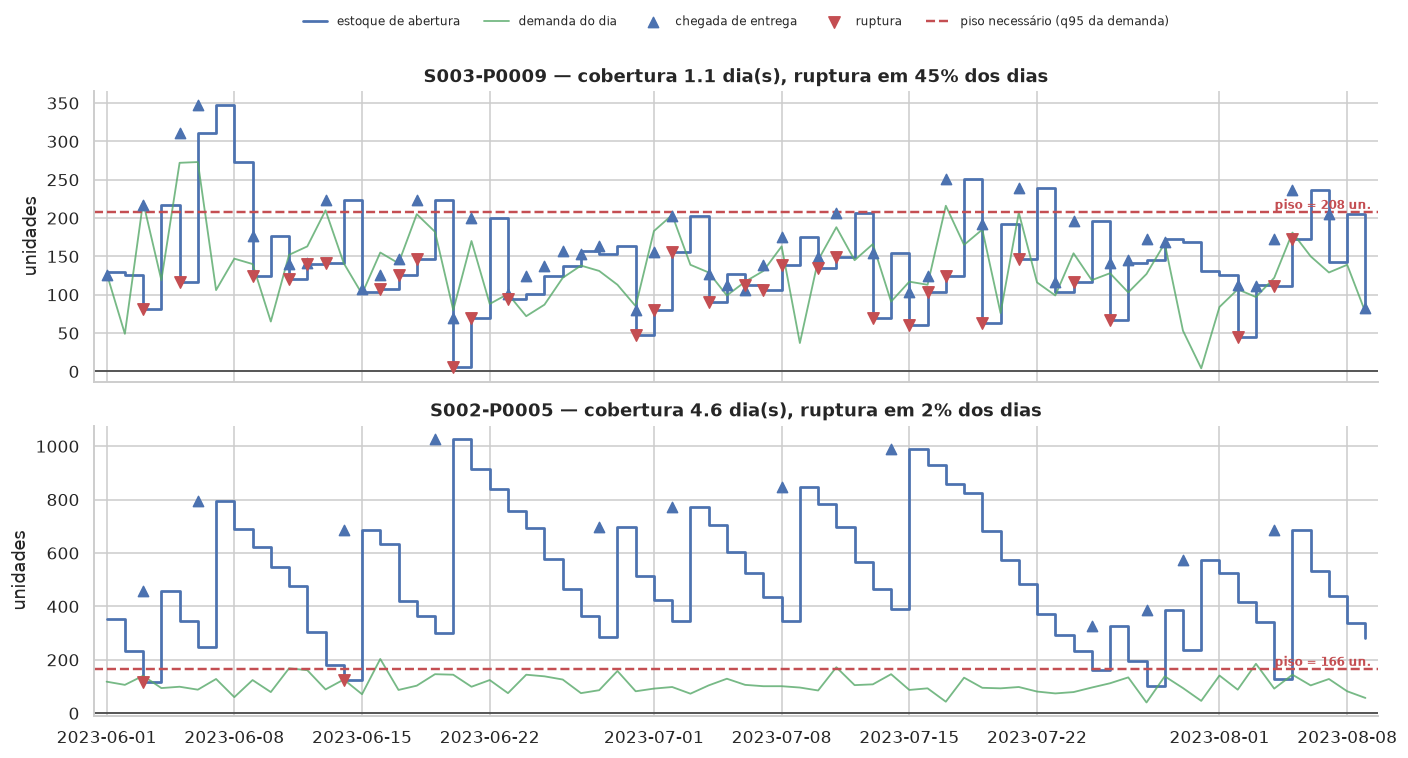

In [3]:
# Estoque-piso: a demanda que precisa ser atendida para servir 95% dos dias
piso = vendas.groupby("sku")["demanda"].quantile(NIVEL_SERVICO)

def dente_de_serra(ax, sku, inicio="2023-06-01", fim="2023-08-09"):
    "Desenha o ciclo de reposição de um SKU em uma janela de tempo."
    g = vendas[(vendas["sku"] == sku) & (vendas["data"].between(inicio, fim))]
    ax.plot(g["data"], g["estoque"], color="#4C72B0", lw=1.8, drawstyle="steps-post",
            label="estoque de abertura")
    ax.plot(g["data"], g["demanda"], color="#55A868", lw=1.2, alpha=0.8, label="demanda do dia")

    entregas = g[g["entrada"] > 0]
    ax.scatter(entregas["data"], entregas["estoque"] + entregas["entrada"] - entregas["vendas"],
               marker="^", s=45, color="#4C72B0", zorder=5, label="chegada de entrega")

    rupturas = g[g["ruptura"]]
    ax.scatter(rupturas["data"], rupturas["estoque"], marker="v", s=55, color="#C44E52",
               zorder=6, label="ruptura")

    ax.axhline(piso[sku], color="#C44E52", lw=1.6, ls="--",
               label="piso necessário (q95 da demanda)")
    ax.annotate(f"piso = {piso[sku]:.0f} un.", xy=(0.995, piso[sku]), xycoords=("axes fraction", "data"),
                ha="right", va="bottom", fontsize=8, color="#C44E52", weight="bold")
    ax.axhline(0, color="#333333", lw=1)

    cob = g["estoque"].mean() / g["demanda"].mean()
    ax.set_title(f"{sku} — cobertura {cob:.1f} dia(s), ruptura em "
                 f"{vendas[vendas['sku'] == sku]['ruptura'].mean():.0%} dos dias")
    ax.set_ylabel("unidades")
    ax.margins(x=0.01)


critico = vendas.groupby("sku")["ruptura"].mean().idxmax()
folgado = (vendas.groupby("sku")["estoque"].mean() / vendas.groupby("sku")["demanda"].mean()).idxmax()

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
dente_de_serra(axes[0], critico)
dente_de_serra(axes[1], folgado)
axes[0].legend(frameon=False, ncol=5, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, 1.30))
sns.despine(); plt.tight_layout(); plt.show()

A linha em degraus é o estoque: sobe de repente a cada entrega e desce com as vendas. Lemos a **altura** do dente como o capital investido por reposição, a **largura** como o tempo que ele fica parado e o **vale** como a margem antes da prateleira vazia; a linha da demanda é o que precisa ser atendido, e cada triângulo vermelho marca um dia em que o vale ficou abaixo dela.

O contraste entre os dois SKUs resume o problema. **Em cima, o SKU crítico**: dentes baixos e estreitos — recebe pouco, quase todo dia. O estoque oscila em torno do piso e o cruza para baixo o tempo todo, e cada cruzamento é uma ruptura (triângulo vermelho): pouco capital, mas vivendo no limite. **Embaixo, o folgado**: dentes altos e largos — recebe muito, de seis em seis dias; o vale nunca se aproxima do piso e por isso quase não rompe, ao custo de capital parado no topo. Repare que a linha verde da demanda oscila o bastante para que um único dia acima da média atravesse um vale baixo.

In [4]:
# Anatomia do dente: vale, topo e tamanho da entrega, por SKU
vales, ciclos = {}, {}
for sku, grp in vendas.groupby("sku"):
    g = grp.reset_index(drop=True)
    ciclo = (g["entrada"].fillna(0) > 0).shift(1, fill_value=False).cumsum()
    vales[sku] = g.groupby(ciclo)["estoque"].min()
    ciclos[sku] = len(vales[sku])

por_sku = vendas.groupby("sku").agg(
    categoria=("categoria", "first"), demanda=("demanda", "mean"), estoque=("estoque", "mean"),
    preco=("preco_ref", "first"), ruptura=("ruptura", "mean"), capital=("valor_estoque", "mean"),
    receita=("receita", "sum"), perda=("receita_perdida", "sum"), entregue=("entrada", "sum"))
por_sku["receita_ano"] = por_sku["receita"] / ANOS
por_sku["perda_ano"] = por_sku["perda"] / ANOS
por_sku["cobertura"] = por_sku["estoque"] / por_sku["demanda"]
por_sku["giro"] = 365 / por_sku["cobertura"]
por_sku["regime"] = prazo_sku
por_sku["piso"] = piso
por_sku["vale"] = pd.Series({k: v.mean() for k, v in vales.items()})
por_sku["Q"] = por_sku["entregue"] / pd.Series(ciclos)      # tamanho médio da entrega
por_sku["topo"] = por_sku["vale"] + por_sku["Q"]
por_sku["folga_no_vale"] = por_sku["vale"] - por_sku["piso"]

anatomia = por_sku.groupby("regime").agg(
    SKUs=("demanda", "size"), demanda=("demanda", "mean"), vale=("vale", "mean"),
    topo=("topo", "mean"), entrega_Q=("Q", "mean"), piso=("piso", "mean"),
    folga_no_vale=("folga_no_vale", "mean"), ruptura=("ruptura", "mean")).round(1)
anatomia.index.name = "regime (prazo, dias)"
print("Anatomia do dente de serra, por regime de reposição")
print(anatomia.to_markdown(tablefmt="grid"))

Anatomia do dente de serra, por regime de reposição
+------------------------+--------+-----------+--------+--------+-------------+--------+-----------------+-----------+
|   regime (prazo, dias) |   SKUs |   demanda |   vale |   topo |   entrega_Q |   piso |   folga_no_vale |   ruptura |
+========================+========+===========+========+========+=============+========+=================+===========+
|                      0 |     29 |     105.5 |  121.2 |  238.4 |       117.2 |  181.5 |           -60.3 |       0.3 |
+------------------------+--------+-----------+--------+--------+-------------+--------+-----------------+-----------+
|                      1 |     21 |     101.7 |  135.8 |  386.7 |       250.9 |  176.5 |           -40.7 |       0.1 |
+------------------------+--------+-----------+--------+--------+-------------+--------+-----------------+-----------+
|                      2 |     26 |     105.8 |  170.3 |  590.3 |       419.9 |  184.3 |           -14   |       0.

A tabela quantifica os painéis: da esquerda para a direita, a entrega cresce de 117 para 565 unidades e o topo de 238 para 776. Mas o que decide é a **folga no vale** — quanto o fundo fica acima do piso necessário:

| regime | folga no vale | ruptura |
|---|---|---|
| 0 (mesmo dia) | **−60 un.** | 30% |
| 1 | −41 un. | 11% |
| 2 | −14 un. | 7% |
| 3 (três dias) | **+35 un.** | 4% |

O dente do regime crítico **mergulha 60 unidades abaixo do piso**: não recebe pouco no total — recebe todo dia —, mas o fundo do ciclo não tem margem, e qualquer dia acima da média corta o dente. A seção 3 verifica se a causa está na cadeia ou na política de reposição.

## 3. Por que os SKUs de giro alto rompem

Três causas concorrentes: **(a) falha de fornecimento** (entregas parciais, rupturas longas); **(b) prazo variável** (instável dentro do SKU); **(c) política de pedido** (fornecimento pontual e completo, mas em volume insuficiente). As duas primeiras já foram descartadas na seção 1 — entregas integrais, prazo constante. Resta testar a terceira.

Diagnóstico por regime
+----------+--------+-------------+----------------------+--------+-----------+-----------+
|   regime |   SKUs |   cobertura |   intervalo_entregas |   giro |   ruptura |   demanda |
+==========+========+=============+======================+========+===========+===========+
|        0 |     29 |        1.29 |                 1.37 | 284.92 |      0.29 |    105.54 |
+----------+--------+-------------+----------------------+--------+-----------+-----------+
|        1 |     21 |        2.36 |                 2.9  | 155.53 |      0.11 |    101.71 |
+----------+--------+-------------+----------------------+--------+-----------+-----------+
|        2 |     26 |        3.48 |                 4.6  | 105.45 |      0.07 |    105.82 |
+----------+--------+-------------+----------------------+--------+-----------+-----------+
|        3 |     24 |        4.74 |                 6.26 |  77.29 |      0.04 |    103.5  |
+----------+--------+-------------+----------------------

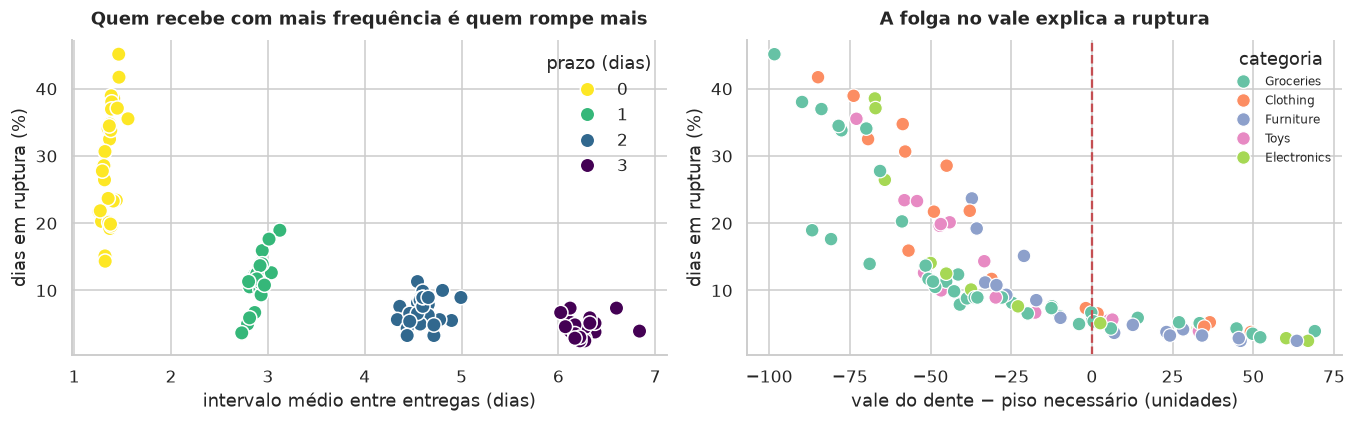

In [5]:
entregas_por_dia = fecha.assign(tem=fecha["entrada"] > 0).groupby("sku")["tem"].mean()
por_sku["intervalo_entregas"] = 1 / entregas_por_dia

diag = por_sku.groupby("regime").agg(
    SKUs=("demanda", "size"), cobertura=("cobertura", "mean"),
    intervalo_entregas=("intervalo_entregas", "mean"), giro=("giro", "mean"),
    ruptura=("ruptura", "mean"), demanda=("demanda", "mean")).round(2)
print("Diagnóstico por regime")
print(diag.to_markdown(tablefmt="grid"))

print("\nCorrelação com a taxa de ruptura do SKU")
for col, rot in [("cobertura", "cobertura de estoque"), ("folga_no_vale", "folga no vale do dente"),
                 ("intervalo_entregas", "intervalo entre entregas"), ("regime", "prazo de entrega"),
                 ("demanda", "demanda média")]:
    print(f"  {rot:26s} {por_sku[col].corr(por_sku['ruptura']):+.3f}")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.5, 4))
sns.scatterplot(data=por_sku, x="intervalo_entregas", y=por_sku["ruptura"] * 100, hue="regime",
                palette="viridis_r", s=90, edgecolor="white", linewidth=1, ax=a1)
a1.set_title("Quem recebe com mais frequência é quem rompe mais", pad=10)
a1.set_xlabel("intervalo médio entre entregas (dias)"); a1.set_ylabel("dias em ruptura (%)")
a1.legend(title="prazo (dias)", frameon=False)

sns.scatterplot(data=por_sku, x="folga_no_vale", y=por_sku["ruptura"] * 100, hue="categoria",
                hue_order=ordem_cat, palette=PALETA, s=80, edgecolor="white", linewidth=0.8, ax=a2)
a2.axvline(0, color="#C44E52", lw=1.5, ls="--")
a2.set_title("A folga no vale explica a ruptura", pad=10)
a2.set_xlabel("vale do dente − piso necessário (unidades)"); a2.set_ylabel("dias em ruptura (%)")
a2.legend(title="categoria", frameon=False, fontsize=8)
sns.despine(); plt.tight_layout(); plt.show()

Cada ponto é um SKU. À esquerda cruzamos o intervalo entre entregas com a taxa de ruptura: uma inclinação **negativa** significa que quem recebe com mais frequência é quem mais rompe — o oposto do que uma falha de fornecimento produziria. À direita, a folga no vale (vale menos piso necessário) contra a ruptura, com o zero do eixo separando quem tem margem de quem não tem.

O gráfico confirma a **hipótese (c)**. O sentido das correlações é o inverso do que uma falha de fornecimento produziria: **os SKUs que mais rompem são os que recebem o melhor serviço** — prazo zero, entrega quase diária (correlações da ruptura com intervalo −0,81 e com prazo −0,83, ambas negativas). A demanda média é igual entre os regimes (+0,21), o que exclui "vender demais". O painel da direita fecha o argumento: a **folga no vale** organiza os 100 SKUs numa curva limpa em torno de zero — à esquerda (vale abaixo do piso), toda a ruptura; à direita, quase nenhuma.

O regime crítico opera em *just-in-time* **sem estoque de segurança**: repõe o suficiente para o dia seguinte e, com o vale 60 unidades abaixo do piso, qualquer demanda acima da média vira ruptura no mesmo dia — daí os episódios de um dia. Não é falha de execução da cadeia, é **dimensionamento do estoque-alvo**. *(Ressalva: prazo e intervalo estão acoplados no dataset e não se separam estatisticamente; nosso diagnóstico se apoia no atendimento integral, no prazo constante e no sinal invertido das correlações.)*

## 4. Quanto estoque deveria haver

A regra da seção 2: o **vale do dente precisa ficar no piso** — o nível de demanda que se quer atender. Adotando 95% de serviço, o piso de cada SKU é o **quantil 95 da sua demanda diária** (medida empírica, sem supor normalidade). Como o estoque oscila entre o vale e o topo, o **estoque médio-alvo** é

$$\text{estoque médio-alvo} = \underbrace{q_{95}(\text{demanda})}_{\text{vale}} + \underbrace{Q/2}_{\text{meia-onda do ciclo}}$$

Esta é a correção que o dente impõe: comparar o piso com o estoque **médio** subestimaria a necessidade, porque o que precisa ficar acima do piso é o **vale**.

In [6]:
por_sku["estoque_alvo"] = por_sku["piso"] + por_sku["Q"] / 2
por_sku["gap_un"] = por_sku["estoque_alvo"] - por_sku["estoque"]
por_sku["gap_rs"] = por_sku["gap_un"] * por_sku["preco"]

alvo_regime = por_sku.groupby("regime").agg(
    SKUs=("demanda", "size"), estoque_atual=("estoque", "mean"),
    estoque_alvo=("estoque_alvo", "mean"), gap_un=("gap_un", "mean"),
    gap_rs=("gap_rs", "mean"), ruptura=("ruptura", "mean")).round(1)
print(f"Estoque-alvo para atender {NIVEL_SERVICO:.0%} dos dias, por regime")
print(alvo_regime.to_markdown(tablefmt="grid"))

deficit = por_sku["gap_rs"] > 0
capital_atual = (por_sku["estoque"] * por_sku["preco"]).sum()
capital_alvo = (por_sku["estoque_alvo"] * por_sku["preco"]).sum()

print(f"\nSKUs abaixo do alvo: {int(deficit.sum())} — déficit de R$ {por_sku['gap_rs'][deficit].sum():,.0f}")
print(f"SKUs acima do alvo : {int((~deficit).sum())} — excesso de R$ {-por_sku['gap_rs'][~deficit].sum():,.0f}")
print(f"\nCapital atual: R$ {capital_atual:,.0f} → alvo: R$ {capital_alvo:,.0f} "
      f"({capital_alvo / capital_atual - 1:+.1%})")
print(f"Custo de carregamento adicional: R$ {(capital_alvo - capital_atual) * CUSTO_CARREGAMENTO:,.0f} / ano")

Estoque-alvo para atender 95% dos dias, por regime
+----------+--------+-----------------+----------------+----------+----------+-----------+
|   regime |   SKUs |   estoque_atual |   estoque_alvo |   gap_un |   gap_rs |   ruptura |
+==========+========+=================+================+==========+==========+===========+
|        0 |     29 |           135.3 |          240.1 |    104.7 |   5719.2 |       0.3 |
+----------+--------+-----------------+----------------+----------+----------+-----------+
|        1 |     21 |           238   |          301.9 |     63.9 |   4285.4 |       0.1 |
+----------+--------+-----------------+----------------+----------+----------+-----------+
|        2 |     26 |           365   |          394.3 |     29.3 |   1652.5 |       0.1 |
+----------+--------+-----------------+----------------+----------+----------+-----------+
|        3 |     24 |           487.3 |          458.4 |    -28.9 |  -2104.4 |       0   |
+----------+--------+-----------------+

SKUs com o vale abaixo do piso: 67 de 100
Perda anual concentrada neles : R$ 11,388,986 (85.3% do total)

+---------------------------------------------------+---------------------+
| item                                              | valor               |
+===================================================+=====================+
| custo de carregamento adicional (25% a.a.)        | R$ 62,077 / ano     |
+---------------------------------------------------+---------------------+
| receita anual em risco nos SKUs sub-dimensionados | R$ 11,388,986 / ano |
+---------------------------------------------------+---------------------+
| margem bruta de equilíbrio                        | 0.5%                |
+---------------------------------------------------+---------------------+


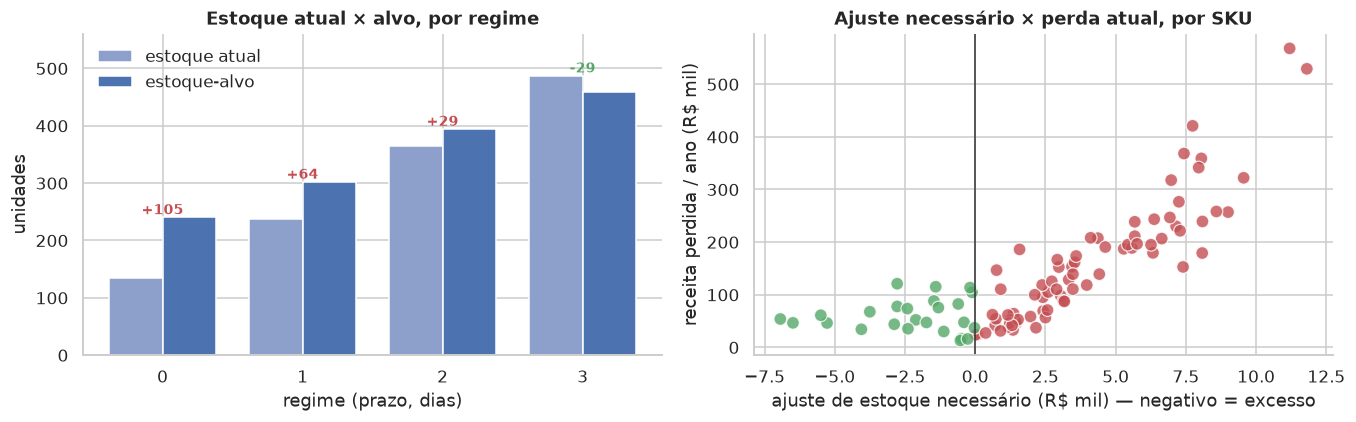

In [7]:
# Quanto da perda atual estaria em SKUs que hoje operam com o vale abaixo do piso?
abaixo_piso = por_sku["folga_no_vale"] < 0
perda_total = por_sku["perda_ano"].sum()
recuperavel = por_sku.loc[abaixo_piso, "perda_ano"].sum()
custo_adicional = (capital_alvo - capital_atual) * CUSTO_CARREGAMENTO

print(f"SKUs com o vale abaixo do piso: {int(abaixo_piso.sum())} de 100")
print(f"Perda anual concentrada neles : R$ {recuperavel:,.0f} ({recuperavel / perda_total:.1%} do total)")
print()
print(pd.DataFrame({
    "item": ["custo de carregamento adicional (25% a.a.)",
             "receita anual em risco nos SKUs sub-dimensionados",
             "margem bruta de equilíbrio"],
    "valor": [f"R$ {custo_adicional:,.0f} / ano", f"R$ {recuperavel:,.0f} / ano",
              f"{custo_adicional / recuperavel:.1%}"],
}).to_markdown(index=False, tablefmt="grid"))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.5, 4))
x = np.arange(len(alvo_regime)); w = 0.38
a1.bar(x - w / 2, alvo_regime["estoque_atual"], w, color="#8DA0CB", label="estoque atual")
a1.bar(x + w / 2, alvo_regime["estoque_alvo"], w, color="#4C72B0", label="estoque-alvo")
for i, (at, al) in enumerate(zip(alvo_regime["estoque_atual"], alvo_regime["estoque_alvo"])):
    a1.text(i, max(at, al), f"{al - at:+.0f}", ha="center", va="bottom", fontsize=9,
            color="#C44E52" if al > at else "#55A868", weight="bold")
a1.set_xticks(x); a1.set_xticklabels(alvo_regime.index)
a1.set_title("Estoque atual × alvo, por regime")
a1.set_xlabel("regime (prazo, dias)"); a1.set_ylabel("unidades"); a1.legend(frameon=False)
a1.margins(y=0.15)

cores = np.where(por_sku["gap_rs"] > 0, "#C44E52", "#55A868")
a2.scatter(por_sku["gap_rs"] / 1000, por_sku["perda_ano"] / 1000, c=cores, s=70,
           alpha=0.8, edgecolor="white", linewidth=0.8)
a2.axvline(0, color="#333333", lw=1)
a2.set_title("Ajuste necessário × perda atual, por SKU")
a2.set_xlabel("ajuste de estoque necessário (R$ mil) — negativo = excesso")
a2.set_ylabel("receita perdida / ano (R$ mil)")
sns.despine(); plt.tight_layout(); plt.show()

À esquerda pomos lado a lado o estoque atual e o estoque-alvo, por regime de prazo — a diferença entre as barras é o ajuste necessário. À direita, cada ponto é um SKU: à direita do zero falta estoque, à esquerda sobra, e a altura é quanto ele perde por ano; o quadrante que nos interessa é o superior direito, onde falta estoque **e** a perda é alta.

Vemos que **75 dos 100 SKUs operam abaixo do alvo**, com déficit de **R\$ 305 mil**; os outros 25 têm excesso de apenas R\$ 57 mil. Levar a rede ao alvo exige **+12,5% de capital** (R\$ 1,98 M → 2,23 M), a um custo de **R\$ 37 a 62 mil/ano** (15%–25%). Esses valores protegem os **R\$ 11,4 milhões/ano** hoje em risco nos 67 SKUs com o vale abaixo do piso (85% de toda a perda): a **margem bruta de equilíbrio é de 0,3% a 0,5%**, superada por qualquer operação de varejo. O ajuste é assimétrico — os regimes 0, 1 e 2 sobem, e o regime 3 pode até **liberar** estoque.

Vale registrar o que o dente de serra corrigiu: comparar o piso com o estoque **médio** indicaria excesso e sugeriria liberar capital; comparar com o **vale**, onde a ruptura de fato ocorre, inverte o sinal — faltam ~R\$ 250 mil líquidos. A oscilação do estoque não é detalhe, é o que determina a resposta.

## 5. Onde agir primeiro?

Os 10 SKUs com maior receita perdida por ano
+------------+-------------+-------------+-----------+-----------------+---------------+------------------+
| sku        | categoria   |   cobertura |   ruptura |   folga_no_vale |   ajuste (R$) |   perda/ano (R$) |
+============+=============+=============+===========+=================+===============+==================+
| S004-P0012 | Electronics |         1.2 |       0.4 |           -67.1 |       11195   |           568134 |
+------------+-------------+-------------+-----------+-----------------+---------------+------------------+
| S002-P0010 | Groceries   |         1.2 |       0.4 |           -83.8 |       11807.1 |           529318 |
+------------+-------------+-------------+-----------+-----------------+---------------+------------------+
| S003-P0009 | Groceries   |         1.1 |       0.5 |           -98.4 |        7739.9 |           420980 |
+------------+-------------+-------------+-----------+-----------------+---------------+---

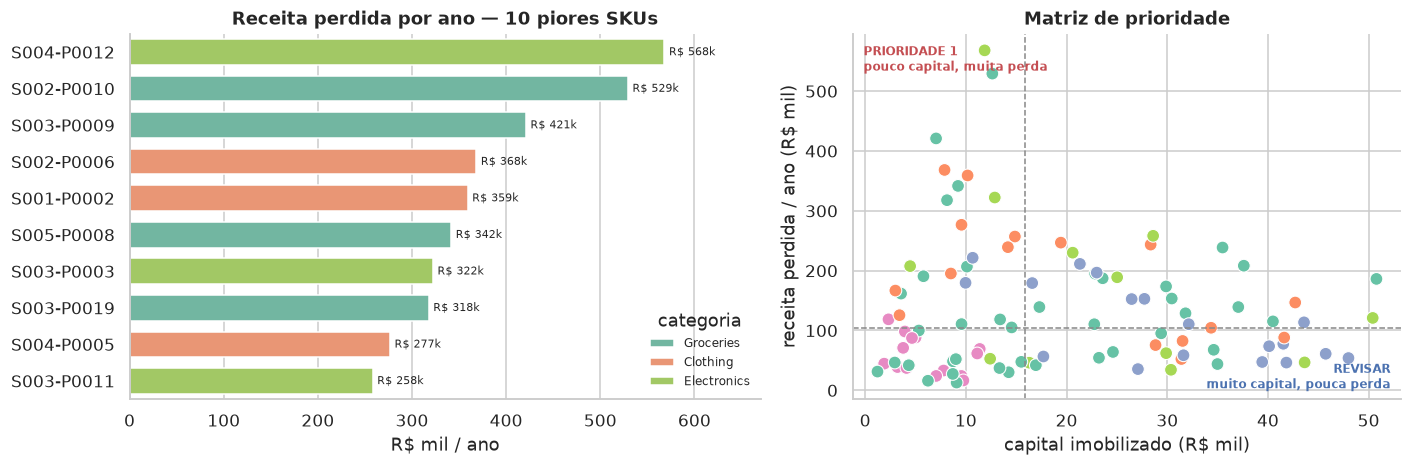

In [8]:
piores = por_sku.nlargest(10, "perda_ano")
print("Os 10 SKUs com maior receita perdida por ano")
print(piores[["categoria", "cobertura", "ruptura", "folga_no_vale", "gap_rs", "perda_ano"]]
      .rename(columns={"gap_rs": "ajuste (R$)", "perda_ano": "perda/ano (R$)"})
      .round(1).to_markdown(tablefmt="grid"))
print(f"\nConcentram {piores['perda_ano'].sum() / por_sku['perda_ano'].sum():.1%} da perda total "
      f"com 10 dos 100 SKUs. Ajustá-los custaria R$ {piores['gap_rs'].sum():,.0f} de capital adicional.")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.4), gridspec_kw={"width_ratios": [1.15, 1]})
cores_cat = dict(zip(ordem_cat, sns.color_palette(PALETA, len(ordem_cat))))
presentes = [c for c in ordem_cat if c in piores["categoria"].values]
sns.barplot(data=piores.reset_index().assign(perda=lambda x: x["perda_ano"] / 1000),
            y="sku", x="perda", hue="categoria", hue_order=presentes,
            palette={c: cores_cat[c] for c in presentes}, dodge=False, width=0.7, ax=a1)
for c in a1.containers:
    a1.bar_label(c, fmt="R$ %.0fk", padding=3, fontsize=7)
a1.set_title("Receita perdida por ano — 10 piores SKUs")
a1.set_xlabel("R$ mil / ano"); a1.set_ylabel("")
a1.legend(title="categoria", frameon=False, fontsize=8); a1.margins(x=0.18)

med_cap, med_perda = por_sku["capital"].median(), por_sku["perda_ano"].median()
sns.scatterplot(data=por_sku, x=por_sku["capital"] / 1000, y=por_sku["perda_ano"] / 1000,
                hue="categoria", hue_order=ordem_cat, palette=PALETA, s=70,
                edgecolor="white", linewidth=0.7, legend=False, ax=a2)
a2.axvline(med_cap / 1000, color="#888888", lw=1, ls="--")
a2.axhline(med_perda / 1000, color="#888888", lw=1, ls="--")
a2.set_title("Matriz de prioridade")
a2.set_xlabel("capital imobilizado (R$ mil)"); a2.set_ylabel("receita perdida / ano (R$ mil)")
a2.text(0.02, 0.97, "PRIORIDADE 1\npouco capital, muita perda", transform=a2.transAxes,
        fontsize=8, va="top", color="#C44E52", weight="bold")
a2.text(0.98, 0.03, "REVISAR\nmuito capital, pouca perda", transform=a2.transAxes,
        fontsize=8, ha="right", color="#4C72B0", weight="bold")
sns.despine(); plt.tight_layout(); plt.show()

À esquerda estão os 10 SKUs que mais perdem por ano. À direita, a matriz de prioridade: capital imobilizado no eixo horizontal, perda anual no vertical — e cada quadrante pede uma ação diferente; em cima à esquerda (pouco capital, muita perda) elevamos o vale, embaixo à direita (muito capital, pouca perda) liberamos capital.

Os **10 piores SKUs concentram 28% da perda anual** prendendo pouco capital — corrigi-los custa uma fração do ajuste e captura mais de um quarto do benefício. A **matriz de prioridade** organiza a ação: no quadrante superior esquerdo (pouco capital, muita perda), elevar o vale; no inferior direito (muito capital, pouca perda, sobretudo móveis), liberar capital. Executados juntos, o aumento líquido de capital cai bem abaixo dos R\$ 250 mil.

## 6. O que o modelo precisa entregar

É a razão de a fase 0 existir, e o dente a torna precisa. O estoque-alvo é $q_{95}(\text{demanda}) + Q/2$: o termo $Q/2$ é decisão logística, mas $q_{95}(\text{demanda})$ é **o que o modelo precisa prever**.

> O modelo não precisa acertar a demanda média. Precisa acertar o **quantil superior** da demanda.

Prever a média atenderia ~metade dos dias. A diferença é material: a média da demanda é 104 unidades; o q95, 188 — **80% acima**.

In [9]:
print(pd.DataFrame({
    "estatística da demanda diária": ["média", "mediana", "quantil 90", "quantil 95", "quantil 98"],
    "unidades": [vendas["demanda"].mean(), vendas["demanda"].median(),
                 vendas["demanda"].quantile(.90), vendas["demanda"].quantile(.95),
                 vendas["demanda"].quantile(.98)],
}).round(1).to_markdown(index=False, tablefmt="grid"))

# Custo assimétrico do erro: subestimar gera ruptura, superestimar gera capital parado
perda_por_unidade = (vendas["receita_perdida"].sum() / vendas["perdida_un"].sum())
custo_por_unidade_estocada = vendas["preco_ref"].mean() * CUSTO_CARREGAMENTO
print(f"\nCusto de 1 unidade a MENOS do que o necessário (venda perdida): R$ {perda_por_unidade:,.2f}")
print(f"Custo de 1 unidade a MAIS  do que o necessário (carregamento/ano): R$ {custo_por_unidade_estocada:,.2f}")
print(f"Razão de assimetria: {perda_por_unidade / custo_por_unidade_estocada:.0f} para 1")

+---------------------------------+------------+
| estatística da demanda diária   |   unidades |
+=================================+============+
| média                           |      104.3 |
+---------------------------------+------------+
| mediana                         |      100   |
+---------------------------------+------------+
| quantil 90                      |      166   |
+---------------------------------+------------+
| quantil 95                      |      188   |
+---------------------------------+------------+
| quantil 98                      |      215   |
+---------------------------------+------------+

Custo de 1 unidade a MENOS do que o necessário (venda perdida): R$ 58.38
Custo de 1 unidade a MAIS  do que o necessário (carregamento/ano): R$ 16.85
Razão de assimetria: 3 para 1


**O que a modelagem precisa fazer.**

1. **O alvo é um quantil, não a média** — o modelo deve estimar o quantil 95 da demanda por SKU-dia, o que muda a técnica: **regressão quantílica** (pinball loss), não mínimos quadrados.
2. **A métrica deve ser assimétrica** — uma unidade a menos custa ~3× mais (venda perdida) que uma a mais (carregamento). RMSE/MAE tratam os dois erros como iguais e escolheriam o modelo errado; a **pinball loss em 0,95** é a métrica coerente.
3. **Os preditores seguem restritos** aos disponíveis antes do dia (categoria, loja, estação, clima, epidemia, promoção, desconto); `estoque`, `vendas` e `pedidos` são vazamento.
4. **A interação epidemia × categoria** (fase 0a) precisa ser codificada — um modelo aditivo erra nos extremos, e errar para baixo é o erro caro.

---

A consolidação das três partes da fase 0 está em [04_fase0_conclusoes.ipynb](04_fase0_conclusoes.ipynb).